# 2 - Forecast Nasdaq index using LSTMs and Keras library

In [277]:
import numpy as np 
import pandas as pd 
 
import matplotlib.pyplot as plt 
 

In [278]:

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras import metrics
 

In [279]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
 

In [280]:
df = pd.read_csv('NASDAQ.csv')
L = len(df)
print(L)

252


In [281]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
247,2017-12-26,6928.919922,6942.140137,6915.560059,6936.250000,6936.250000,1304340000
248,2017-12-27,6941.450195,6955.379883,6931.339844,6939.339844,6939.339844,1409540000
249,2017-12-28,6953.379883,6954.799805,6936.750000,6950.160156,6950.160156,1311320000
250,2017-12-29,6952.609863,6954.979980,6903.390137,6903.390137,6903.390137,1571730000
251,2018-01-02,6937.649902,7006.910156,6924.080078,7006.899902,7006.899902,1914930000


In [282]:
# coluna 4, Close

In [283]:
Y = np.array([df.iloc[:,4]])

In [284]:
Y

array([[5429.080078, 5477.      , 5487.939941, 5521.060059, 5531.819824,
        5551.819824, 5563.649902, 5547.490234, 5574.120117, 5538.72998 ,
        5555.649902, 5540.080078, 5555.330078, 5552.939941, 5600.959961,
        5656.339844, 5655.180176, 5660.779785, 5613.709961, 5614.790039,
        5642.649902, 5636.200195, 5666.77002 , 5663.549805, 5674.220215,
        5682.450195, 5715.180176, 5734.129883, 5763.959961, 5782.569824,
        5819.439941, 5814.899902, 5838.580078, 5865.950195, 5860.629883,
        5835.509766, 5845.310059, 5861.899902, 5825.439941, 5904.029785,
        5861.220215, 5870.75    , 5849.180176, 5833.930176, 5837.549805,
        5838.810059, 5861.72998 , 5875.779785, 5856.819824, 5900.049805,
        5900.759766, 5901.      , 5901.529785, 5793.830078, 5821.640137,
        5817.689941, 5828.740234, 5840.370117, 5875.140137, 5897.549805,
        5914.339844, 5911.740234, 5894.680176, 5898.609863, 5864.47998 ,
        5878.950195, 5877.810059, 5880.930176, 5866

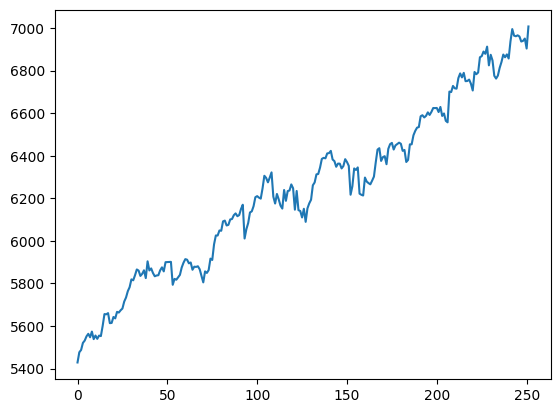

In [285]:
plt.figure(1)
plt.plot(Y[0,:])
plt.show(block= False)

In [286]:
X1 = Y[:,0:L-5]
X2 = Y[:,1:L-4]
X3 = Y[:,2:L-3]

In [287]:
L-5

247

In [288]:
L-4

248

In [289]:
L-3

249

In [290]:
X1.shape

(1, 247)

In [291]:
X2.shape

(1, 247)

In [292]:
X3.shape

(1, 247)

In [293]:
X1

array([[5429.080078, 5477.      , 5487.939941, 5521.060059, 5531.819824,
        5551.819824, 5563.649902, 5547.490234, 5574.120117, 5538.72998 ,
        5555.649902, 5540.080078, 5555.330078, 5552.939941, 5600.959961,
        5656.339844, 5655.180176, 5660.779785, 5613.709961, 5614.790039,
        5642.649902, 5636.200195, 5666.77002 , 5663.549805, 5674.220215,
        5682.450195, 5715.180176, 5734.129883, 5763.959961, 5782.569824,
        5819.439941, 5814.899902, 5838.580078, 5865.950195, 5860.629883,
        5835.509766, 5845.310059, 5861.899902, 5825.439941, 5904.029785,
        5861.220215, 5870.75    , 5849.180176, 5833.930176, 5837.549805,
        5838.810059, 5861.72998 , 5875.779785, 5856.819824, 5900.049805,
        5900.759766, 5901.      , 5901.529785, 5793.830078, 5821.640137,
        5817.689941, 5828.740234, 5840.370117, 5875.140137, 5897.549805,
        5914.339844, 5911.740234, 5894.680176, 5898.609863, 5864.47998 ,
        5878.950195, 5877.810059, 5880.930176, 5866

In [294]:
X2

array([[5477.      , 5487.939941, 5521.060059, 5531.819824, 5551.819824,
        5563.649902, 5547.490234, 5574.120117, 5538.72998 , 5555.649902,
        5540.080078, 5555.330078, 5552.939941, 5600.959961, 5656.339844,
        5655.180176, 5660.779785, 5613.709961, 5614.790039, 5642.649902,
        5636.200195, 5666.77002 , 5663.549805, 5674.220215, 5682.450195,
        5715.180176, 5734.129883, 5763.959961, 5782.569824, 5819.439941,
        5814.899902, 5838.580078, 5865.950195, 5860.629883, 5835.509766,
        5845.310059, 5861.899902, 5825.439941, 5904.029785, 5861.220215,
        5870.75    , 5849.180176, 5833.930176, 5837.549805, 5838.810059,
        5861.72998 , 5875.779785, 5856.819824, 5900.049805, 5900.759766,
        5901.      , 5901.529785, 5793.830078, 5821.640137, 5817.689941,
        5828.740234, 5840.370117, 5875.140137, 5897.549805, 5914.339844,
        5911.740234, 5894.680176, 5898.609863, 5864.47998 , 5878.950195,
        5877.810059, 5880.930176, 5866.77002 , 5836

In [295]:
X3

array([[5487.939941, 5521.060059, 5531.819824, 5551.819824, 5563.649902,
        5547.490234, 5574.120117, 5538.72998 , 5555.649902, 5540.080078,
        5555.330078, 5552.939941, 5600.959961, 5656.339844, 5655.180176,
        5660.779785, 5613.709961, 5614.790039, 5642.649902, 5636.200195,
        5666.77002 , 5663.549805, 5674.220215, 5682.450195, 5715.180176,
        5734.129883, 5763.959961, 5782.569824, 5819.439941, 5814.899902,
        5838.580078, 5865.950195, 5860.629883, 5835.509766, 5845.310059,
        5861.899902, 5825.439941, 5904.029785, 5861.220215, 5870.75    ,
        5849.180176, 5833.930176, 5837.549805, 5838.810059, 5861.72998 ,
        5875.779785, 5856.819824, 5900.049805, 5900.759766, 5901.      ,
        5901.529785, 5793.830078, 5821.640137, 5817.689941, 5828.740234,
        5840.370117, 5875.140137, 5897.549805, 5914.339844, 5911.740234,
        5894.680176, 5898.609863, 5864.47998 , 5878.950195, 5877.810059,
        5880.930176, 5866.77002 , 5836.160156, 5805

In [296]:
Y[:,2]

array([5487.939941])

In [297]:
X= np.concatenate([X1,X2,X3],axis=0) # concatenar 
print(X)

[[5429.080078 5477.       5487.939941 5521.060059 5531.819824 5551.819824
  5563.649902 5547.490234 5574.120117 5538.72998  5555.649902 5540.080078
  5555.330078 5552.939941 5600.959961 5656.339844 5655.180176 5660.779785
  5613.709961 5614.790039 5642.649902 5636.200195 5666.77002  5663.549805
  5674.220215 5682.450195 5715.180176 5734.129883 5763.959961 5782.569824
  5819.439941 5814.899902 5838.580078 5865.950195 5860.629883 5835.509766
  5845.310059 5861.899902 5825.439941 5904.029785 5861.220215 5870.75
  5849.180176 5833.930176 5837.549805 5838.810059 5861.72998  5875.779785
  5856.819824 5900.049805 5900.759766 5901.       5901.529785 5793.830078
  5821.640137 5817.689941 5828.740234 5840.370117 5875.140137 5897.549805
  5914.339844 5911.740234 5894.680176 5898.609863 5864.47998  5878.950195
  5877.810059 5880.930176 5866.77002  5836.160156 5805.149902 5856.790039
  5849.470215 5863.029785 5916.779785 5910.52002  5983.819824 6025.490234
  6025.22998  6048.939941 6047.609863 6091

In [298]:
X= np.transpose(X)
print(X)

[[5429.080078 5477.       5487.939941]
 [5477.       5487.939941 5521.060059]
 [5487.939941 5521.060059 5531.819824]
 [5521.060059 5531.819824 5551.819824]
 [5531.819824 5551.819824 5563.649902]
 [5551.819824 5563.649902 5547.490234]
 [5563.649902 5547.490234 5574.120117]
 [5547.490234 5574.120117 5538.72998 ]
 [5574.120117 5538.72998  5555.649902]
 [5538.72998  5555.649902 5540.080078]
 [5555.649902 5540.080078 5555.330078]
 [5540.080078 5555.330078 5552.939941]
 [5555.330078 5552.939941 5600.959961]
 [5552.939941 5600.959961 5656.339844]
 [5600.959961 5656.339844 5655.180176]
 [5656.339844 5655.180176 5660.779785]
 [5655.180176 5660.779785 5613.709961]
 [5660.779785 5613.709961 5614.790039]
 [5613.709961 5614.790039 5642.649902]
 [5614.790039 5642.649902 5636.200195]
 [5642.649902 5636.200195 5666.77002 ]
 [5636.200195 5666.77002  5663.549805]
 [5666.77002  5663.549805 5674.220215]
 [5663.549805 5674.220215 5682.450195]
 [5674.220215 5682.450195 5715.180176]
 [5682.450195 5715.180176

In [299]:
Y = np.transpose(Y[:,3:L-2])

In [300]:
Y

array([[5521.060059],
       [5531.819824],
       [5551.819824],
       [5563.649902],
       [5547.490234],
       [5574.120117],
       [5538.72998 ],
       [5555.649902],
       [5540.080078],
       [5555.330078],
       [5552.939941],
       [5600.959961],
       [5656.339844],
       [5655.180176],
       [5660.779785],
       [5613.709961],
       [5614.790039],
       [5642.649902],
       [5636.200195],
       [5666.77002 ],
       [5663.549805],
       [5674.220215],
       [5682.450195],
       [5715.180176],
       [5734.129883],
       [5763.959961],
       [5782.569824],
       [5819.439941],
       [5814.899902],
       [5838.580078],
       [5865.950195],
       [5860.629883],
       [5835.509766],
       [5845.310059],
       [5861.899902],
       [5825.439941],
       [5904.029785],
       [5861.220215],
       [5870.75    ],
       [5849.180176],
       [5833.930176],
       [5837.549805],
       [5838.810059],
       [5861.72998 ],
       [5875.779785],
       [58

In [301]:
L-2

250

In [302]:
scaler = MinMaxScaler() #normalizar
scaler.fit(X)
X = scaler.transform(X)

In [303]:
X


array([[0.        , 0.        , 0.        ],
       [0.03060647, 0.00720795, 0.02198014],
       [0.03759381, 0.02902967, 0.02912086],
       [0.05874764, 0.03611891, 0.04239384],
       [0.0656199 , 0.04929622, 0.05024487],
       [0.07839391, 0.05709066, 0.03952051],
       [0.08594978, 0.0464436 , 0.05719342],
       [0.0756286 , 0.06398912, 0.03370678],
       [0.09263711, 0.04067177, 0.04493567],
       [0.07003342, 0.05181973, 0.03460277],
       [0.08084018, 0.04156131, 0.04472342],
       [0.07089573, 0.05160901, 0.04313721],
       [0.08063591, 0.05003423, 0.07500566],
       [0.07910932, 0.08167298, 0.11175849],
       [0.10977972, 0.11816089, 0.11098887],
       [0.14515087, 0.11739682, 0.11470505],
       [0.14441019, 0.12108621, 0.08346719],
       [0.14798666, 0.09007352, 0.08418399],
       [0.11792315, 0.09078514, 0.10267317],
       [0.118613  , 0.10914105, 0.09839282],
       [0.1364071 , 0.10489156, 0.11868047],
       [0.13228767, 0.12503298, 0.11654337],
       [0.

In [304]:
scaler1 = MinMaxScaler()
scaler1.fit(Y)
Y = scaler1.transform(Y)

In [305]:
Y

array([[0.        ],
       [0.00730119],
       [0.02087248],
       [0.02889995],
       [0.01793457],
       [0.03600466],
       [0.01199018],
       [0.02347143],
       [0.01290631],
       [0.02325441],
       [0.02163255],
       [0.05421722],
       [0.09179603],
       [0.09100912],
       [0.09480882],
       [0.06286892],
       [0.06360182],
       [0.08250653],
       [0.07812998],
       [0.09887358],
       [0.09668845],
       [0.10392901],
       [0.10951358],
       [0.13172298],
       [0.14458157],
       [0.1648232 ],
       [0.17745119],
       [0.20246993],
       [0.19938923],
       [0.21545775],
       [0.23403013],
       [0.23041996],
       [0.21337434],
       [0.22002447],
       [0.23128175],
       [0.20654132],
       [0.25986958],
       [0.23082054],
       [0.23728711],
       [0.2226506 ],
       [0.21230249],
       [0.21475864],
       [0.2156138 ],
       [0.23116644],
       [0.24070014],
       [0.22783459],
       [0.25716891],
       [0.257

In [306]:
# criar 3 dimensões de objetos
X= np.reshape(X, (X.shape[0],1,X.shape[1]))
X

array([[[0.        , 0.        , 0.        ]],

       [[0.03060647, 0.00720795, 0.02198014]],

       [[0.03759381, 0.02902967, 0.02912086]],

       [[0.05874764, 0.03611891, 0.04239384]],

       [[0.0656199 , 0.04929622, 0.05024487]],

       [[0.07839391, 0.05709066, 0.03952051]],

       [[0.08594978, 0.0464436 , 0.05719342]],

       [[0.0756286 , 0.06398912, 0.03370678]],

       [[0.09263711, 0.04067177, 0.04493567]],

       [[0.07003342, 0.05181973, 0.03460277]],

       [[0.08084018, 0.04156131, 0.04472342]],

       [[0.07089573, 0.05160901, 0.04313721]],

       [[0.08063591, 0.05003423, 0.07500566]],

       [[0.07910932, 0.08167298, 0.11175849]],

       [[0.10977972, 0.11816089, 0.11098887]],

       [[0.14515087, 0.11739682, 0.11470505]],

       [[0.14441019, 0.12108621, 0.08346719]],

       [[0.14798666, 0.09007352, 0.08418399]],

       [[0.11792315, 0.09078514, 0.10267317]],

       [[0.118613  , 0.10914105, 0.09839282]],

       [[0.1364071 , 0.10489156, 0.11868

In [307]:
X.shape

(247, 1, 3)

In [308]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25) # 25% para teste


In [309]:
X_train[:2]

array([[[0.82127901, 0.84825014, 0.86174868]],

       [[0.60125956, 0.57672505, 0.48375404]]])

In [310]:
X_test[:3]

array([[[0.08594978, 0.0464436 , 0.05719342]],

       [[0.6087515 , 0.59145077, 0.57085802]],

       [[0.46241898, 0.46080424, 0.46811162]]])

In [311]:
Y_train[:2]

array([[0.84597949],
       [0.49908404]])

In [312]:
Y_test[:2]

array([[0.01199018],
       [0.57126963]])

In [313]:
model = Sequential()
# Cria um modelo sequencial no Keras, no qual as camadas serão empilhadas uma após a outra.


In [314]:
model.add(LSTM(10,activation = 'tanh',input_shape = (1,3),recurrent_activation= 'hard_sigmoid'))

#Adiciona uma camada LSTM com:

#10 unidades (neurônios da memória de longo prazo),

#Função de ativação principal tanh (para a saída da célula),

#input_shape=(1, 3) → sequência com 1 passo de tempo e 3 features por passo,

#recurrent_activation='hard_sigmoid' → ativação usada nos portões internos da LSTM (input, forget e output).


/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [315]:
 #Adiciona uma camada densa (totalmente conectada) com 1 neurônio, usada para gerar a saída final do modelo.

model.add(Dense(1))

In [316]:
model.compile(loss= 'mean_squared_error',optimizer = 'rmsprop', metrics=['mae'])


#Configura o modelo definindo:

#Função de perda: MSE (erro quadrático médio),

#Otimizador: RMSprop (ajuste adaptativo da taxa de aprendizado),

#Métrica extra para acompanhamento: MAE (erro absoluto médio).

In [317]:
#Treina o modelo usando os dados de treino (X_train, Y_train) por 50 épocas (passadas completas pelo dataset), 
#com verbose=2 (mostra o progresso resumido no terminal).

  

 # loss nem baixo no final 10^-4, com mae menor
model.fit(X_train,Y_train,epochs=50,verbose=2)

Epoch 1/50
6/6 - 1s - 102ms/step - loss: 0.3011 - mae: 0.4789
Epoch 2/50
6/6 - 0s - 5ms/step - loss: 0.2602 - mae: 0.4411
Epoch 3/50
6/6 - 0s - 8ms/step - loss: 0.2320 - mae: 0.4135
Epoch 4/50
6/6 - 0s - 7ms/step - loss: 0.2081 - mae: 0.3886
Epoch 5/50
6/6 - 0s - 5ms/step - loss: 0.1861 - mae: 0.3655
Epoch 6/50
6/6 - 0s - 5ms/step - loss: 0.1658 - mae: 0.3424
Epoch 7/50
6/6 - 0s - 5ms/step - loss: 0.1469 - mae: 0.3201
Epoch 8/50
6/6 - 0s - 5ms/step - loss: 0.1293 - mae: 0.2987
Epoch 9/50
6/6 - 0s - 5ms/step - loss: 0.1129 - mae: 0.2765
Epoch 10/50
6/6 - 0s - 6ms/step - loss: 0.0982 - mae: 0.2550
Epoch 11/50
6/6 - 0s - 5ms/step - loss: 0.0850 - mae: 0.2350
Epoch 12/50
6/6 - 0s - 6ms/step - loss: 0.0732 - mae: 0.2173
Epoch 13/50
6/6 - 0s - 7ms/step - loss: 0.0625 - mae: 0.2015
Epoch 14/50
6/6 - 0s - 6ms/step - loss: 0.0530 - mae: 0.1867
Epoch 15/50
6/6 - 0s - 8ms/step - loss: 0.0451 - mae: 0.1734
Epoch 16/50
6/6 - 0s - 8ms/step - loss: 0.0383 - mae: 0.1599
Epoch 17/50
6/6 - 0s - 7ms/step

esse input_shape=(1, 3) na LSTM é um dos pontos que mais confunde mesmo.

No Keras, LSTMs esperam entradas no formato 3D:

(batch_size, time_steps, features)


1 (time_steps) → cada exemplo de entrada tem 1 passo de tempo (ou seja, você não está usando uma sequência longa, mas apenas um ponto no tempo).

3 (features) → em cada passo de tempo, existem 3 variáveis de entrada (3 valores diferentes medidos no mesmo momento).



No treino de redes neurais, época (ou epoch) é uma passada completa de todo o conjunto de treino pelo modelo.

- exemplo:

Você tem 100 amostras no X_train.

O modelo vai processar todas essas 100 amostras uma vez → isso é 1 época.

Na próxima época, ele repete o processo, mas agora com pesos um pouco ajustados pela época anterior.

- Por que usar várias épocas:

Porque o modelo não aprende tudo de uma vez. Cada época faz ajustes pequenos nos pesos para diminuir o erro. Com várias épocas, ele refina as previsões até convergir (ou até começar a overfitar).

- Observação:

Mais épocas ≠ melhor sempre.
Poucas épocas → modelo não aprende o suficiente (underfitting).
Muitas épocas → modelo memoriza demais e perde capacidade de generalizar (overfitting).



In [318]:
Predict = model.predict(X_test)
Predict

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


array([[0.04388882],
       [0.58695805],
       [0.45228493],
       [0.04875738],
       [0.5039589 ],
       [0.25033417],
       [0.541016  ],
       [0.45960146],
       [0.9051341 ],
       [0.81483245],
       [0.5375892 ],
       [0.45077583],
       [0.43331403],
       [0.6145592 ],
       [0.51422757],
       [0.48118225],
       [0.41321912],
       [0.609596  ],
       [0.5235154 ],
       [0.48251688],
       [0.9768731 ],
       [0.22889003],
       [0.26479426],
       [0.96657777],
       [0.5505576 ],
       [0.83233654],
       [0.21232855],
       [0.8802822 ],
       [0.6452918 ],
       [0.03326439],
       [0.822371  ],
       [0.22347742],
       [0.204375  ],
       [0.23851411],
       [0.241589  ],
       [0.22785817],
       [0.9213706 ],
       [0.5791385 ],
       [0.42293996],
       [0.6183657 ],
       [0.51322544],
       [0.58325154],
       [0.73624444],
       [0.8618883 ],
       [0.91952527],
       [0.7547925 ],
       [0.22165598],
       [0.385

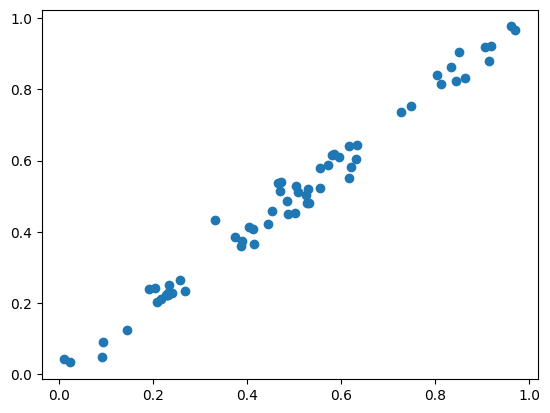

In [319]:
plt.figure(2)
plt.scatter(Y_test,Predict)
plt.show(block= False)
 

In [320]:
#plt.figure(3)
#Test = plt.plot(Y_test)
#Predict= plt.plot(Predict)
#plt.show()

/tmp/ipykernel_15531/1336222652.py:4: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Predict2, Test],["Predicted Data", "Real Data"])


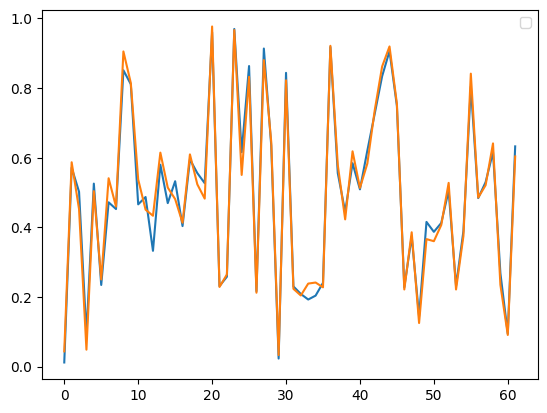

In [321]:
plt.figure(3)
Test = plt.plot(Y_test)
Predict2= plt.plot(Predict)
plt.legend([Predict2, Test],["Predicted Data", "Real Data"])

plt.show()

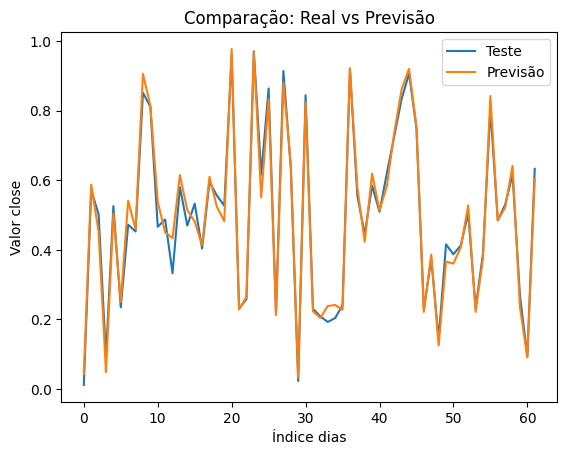

In [322]:
import matplotlib.pyplot as plt

plt.figure(3)
plt.plot(Y_test, label='Teste')      
plt.plot(Predict, label='Previsão')   
plt.legend()                        
plt.title('Comparação: Real vs Previsão')
plt.xlabel('Índice dias')
plt.ylabel('Valor close')
plt.show()